# Image Similarity Search with Databricks Vector Search

End-to-end notebook that:
1. Generates sample images and stores them in a Unity Catalog Volume
2. Computes image embeddings using CLIP (via transformers)
3. Persists embeddings in a Delta table with Change Data Feed
4. Creates a Vector Search index (self-managed embeddings, Delta Sync)
5. Runs similarity queries: given a query image, find the most similar images

**Requirements:** DBR 15.4+ cluster with `transformers`, `torch`, `Pillow` (pre-installed).

## 0 | Setup & Configuration

In [0]:
# ---------------------------------------------------------------------------
# Configuration – change these to match your environment
# ---------------------------------------------------------------------------
CATALOG = "saschas"
SCHEMA  = "image_similarity"
VOLUME  = "images"

IMAGE_TABLE          = f"{CATALOG}.{SCHEMA}.image_embeddings"
VS_ENDPOINT_NAME     = "image_similarity_endpoint"
VS_INDEX_NAME        = f"{CATALOG}.{SCHEMA}.image_similarity_index"
EMBEDDING_DIM        = 512          # CLIP ViT-B/32 output dimension
TOP_K                = 5            # number of similar images to return

VOLUME_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"

print(f"Catalog:      {CATALOG}")
print(f"Schema:       {SCHEMA}")
print(f"Volume path:  {VOLUME_PATH}")
print(f"Image table:  {IMAGE_TABLE}")
print(f"VS endpoint:  {VS_ENDPOINT_NAME}")
print(f"VS index:     {VS_INDEX_NAME}")

Catalog:      sascha_demo_aws_catalog
Schema:       image_similarity
Volume path:  /Volumes/sascha_demo_aws_catalog/image_similarity/images
Image table:  sascha_demo_aws_catalog.image_similarity.image_embeddings
VS endpoint:  image_similarity_endpoint
VS index:     sascha_demo_aws_catalog.image_similarity.image_similarity_index


In [0]:
spark.sql(f"USE CATALOG `{CATALOG}`")
spark.sql(f"USE SCHEMA `{SCHEMA}`")
print(f"Using {CATALOG}.{SCHEMA}")

Using sascha_demo_aws_catalog.image_similarity


## 2 | Create Delta Table for Image Embeddings

In [0]:
spark.sql(f"""
CREATE TABLE IF NOT EXISTS {IMAGE_TABLE} (
  id                STRING        NOT NULL,
  image_uri         STRING        NOT NULL,
  file_name         STRING,
  category          STRING,
  embedding         ARRAY<FLOAT>,
  embedding_dim     INT,
  ingested_at       TIMESTAMP
)
TBLPROPERTIES (delta.enableChangeDataFeed = true)
""")
print(f"Table {IMAGE_TABLE} ready (CDF enabled)")

Table sascha_demo_aws_catalog.image_similarity.image_embeddings ready (CDF enabled)


## 3 | Compute Image Embeddings with CLIP

We use **OpenCLIP** (`open_clip_torch`) with the `ViT-B-32` model to compute 512-dimensional embeddings for each image.  
The same model must be used at query time.

In [0]:
import torch
import open_clip
from PIL import Image as PILImage

# Load CLIP model
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
model.eval()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-5cac63b7-6010-4840-b54a-dc9cbdacdacc/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [0]:
import hashlib
import os
from datetime import datetime

def compute_embedding(image_path: str) -> list:
    """Compute CLIP embedding for a single image."""
    img = PILImage.open(image_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0)
    with torch.no_grad():
        emb = model.encode_image(img_tensor)
        emb = emb / emb.norm(dim=-1, keepdim=True)  # L2 normalize
    return emb.squeeze().tolist()

def make_id(image_uri: str) -> str:
    """Deterministic ID from the image path (for idempotent upserts)."""
    return hashlib.sha256(image_uri.encode()).hexdigest()[:16]

# Scan volume for existing images
rows = []
for root, dirs, files in os.walk(VOLUME_PATH):
    for fname in files:
        # Process common image formats
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            fpath = os.path.join(root, fname)
            # Extract category from parent directory name if structured
            cat = os.path.basename(root) if root != VOLUME_PATH else "uncategorized"
            
            try:
                emb = compute_embedding(fpath)
                rows.append({
                    "id":            make_id(fpath),
                    "image_uri":     fpath,
                    "file_name":     fname,
                    "category":      cat,
                    "embedding":     emb,
                    "embedding_dim": len(emb),
                    "ingested_at":   datetime.utcnow().isoformat(),
                })
            except Exception as e:
                print(f"Skipping {fname}: {e}")

print(f"Computed {len(rows)} embeddings (dim={rows[0]['embedding_dim'] if rows else 'N/A'})")

/home/spark-5cac63b7-6010-4840-b54a-dc/.ipykernel/6522/command-8474442544418919-2517150343:37: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "ingested_at":   datetime.utcnow().isoformat(),


Computed 39 embeddings (dim=512)


In [0]:
from pyspark.sql.types import StructType, StructField, StringType, ArrayType, FloatType, IntegerType, TimestampType
from pyspark.sql.functions import col, lit, current_timestamp

schema = StructType([
    StructField("id",            StringType(),           False),
    StructField("image_uri",     StringType(),           False),
    StructField("file_name",     StringType(),           True),
    StructField("category",      StringType(),           True),
    StructField("embedding",     ArrayType(FloatType()), True),
    StructField("embedding_dim", IntegerType(),          True),
    StructField("ingested_at",   StringType(),           True),
])

df = spark.createDataFrame(rows, schema=schema)

# Idempotent MERGE (no duplicates on re-run)
df.createOrReplaceTempView("new_images")

spark.sql(f"""
MERGE INTO {IMAGE_TABLE} AS target
USING new_images AS source
ON target.id = source.id
WHEN MATCHED THEN UPDATE SET *
WHEN NOT MATCHED THEN INSERT *
""")

row_count = spark.sql(f"SELECT COUNT(*) AS cnt FROM {IMAGE_TABLE}").collect()[0]["cnt"]
print(f"Image table now contains {row_count} rows")

Image table now contains 39 rows


## 3.1 | Data Integrity Checks

In [0]:
# Validate: all rows have embeddings, consistent dimension
checks = spark.sql(f"""
SELECT
  COUNT(*)                                          AS total_rows,
  SUM(CASE WHEN embedding IS NULL THEN 1 ELSE 0 END) AS null_embeddings,
  COUNT(DISTINCT embedding_dim)                     AS distinct_dims,
  MIN(embedding_dim)                                AS min_dim,
  MAX(embedding_dim)                                AS max_dim,
  COUNT(DISTINCT category)                          AS num_categories
FROM {IMAGE_TABLE}
""").collect()[0]

assert checks["total_rows"] > 0,            f"Table is empty!"
assert checks["null_embeddings"] == 0,       f"Found {checks['null_embeddings']} rows without embeddings"
assert checks["distinct_dims"] == 1,         f"Inconsistent embedding dims: min={checks['min_dim']}, max={checks['max_dim']}"
assert checks["min_dim"] == EMBEDDING_DIM,   f"Expected dim={EMBEDDING_DIM}, got {checks['min_dim']}"

print(f"All checks passed:")
print(f"  Total rows:      {checks['total_rows']}")
print(f"  Null embeddings: {checks['null_embeddings']}")
print(f"  Embedding dim:   {checks['min_dim']}")
print(f"  Categories:      {checks['num_categories']}")

All checks passed:
  Total rows:      39
  Null embeddings: 0
  Embedding dim:   512
  Categories:      6


## 4 | Create Vector Search Endpoint & Index

In [0]:
from databricks.vector_search.client import VectorSearchClient
import time

vsc = VectorSearchClient(disable_notice=True)

# --- helpers (same pattern as the PDF RAG demo) ---
def endpoint_exists(vsc, ep_name):
    try:
        return vsc.get_endpoint(ep_name) is not None
    except Exception:
        return False

def wait_for_vs_endpoint(vsc, ep_name, timeout=600):
    t0 = time.time()
    while time.time() - t0 < timeout:
        ep = vsc.get_endpoint(ep_name)
        status = ep.get("endpoint_status", ep).get("state", "UNKNOWN") if isinstance(ep, dict) else "UNKNOWN"
        if status == "ONLINE":
            return
        print(f"  Endpoint status: {status} ... waiting")
        time.sleep(30)
    raise TimeoutError(f"Endpoint {ep_name} not ready after {timeout}s")

def index_exists(vsc, ep_name, idx_name):
    try:
        vsc.get_index(ep_name, idx_name)
        return True
    except Exception:
        return False

def wait_for_index(vsc, ep_name, idx_name, timeout=600):
    t0 = time.time()
    while time.time() - t0 < timeout:
        idx = vsc.get_index(ep_name, idx_name)
        status = idx.describe().get("status", {}).get("ready", False)
        if status:
            return
        print(f"  Index not ready yet ... waiting")
        time.sleep(30)
    raise TimeoutError(f"Index {idx_name} not ready after {timeout}s")

print("Vector Search client ready")

Vector Search client ready


In [0]:
# Create endpoint if it doesn't exist
if not endpoint_exists(vsc, VS_ENDPOINT_NAME):
    print(f"Creating VS endpoint '{VS_ENDPOINT_NAME}' ...")
    vsc.create_endpoint(name=VS_ENDPOINT_NAME, endpoint_type="STANDARD")
else:
    print(f"VS endpoint '{VS_ENDPOINT_NAME}' already exists")

wait_for_vs_endpoint(vsc, VS_ENDPOINT_NAME)
print(f"Endpoint '{VS_ENDPOINT_NAME}' is ONLINE")

VS endpoint 'image_similarity_endpoint' already exists
Endpoint 'image_similarity_endpoint' is ONLINE


In [0]:
# Create Delta Sync index with SELF-MANAGED embeddings
if not index_exists(vsc, VS_ENDPOINT_NAME, VS_INDEX_NAME):
    print(f"Creating index '{VS_INDEX_NAME}' ...")
    vsc.create_delta_sync_index(
        endpoint_name=VS_ENDPOINT_NAME,
        index_name=VS_INDEX_NAME,
        source_table_name=IMAGE_TABLE,
        pipeline_type="TRIGGERED",
        primary_key="id",
        embedding_vector_column="embedding",
        embedding_dimension=EMBEDDING_DIM,
    )
    wait_for_index(vsc, VS_ENDPOINT_NAME, VS_INDEX_NAME)
    print(f"Index '{VS_INDEX_NAME}' is ready")
else:
    print(f"Index '{VS_INDEX_NAME}' already exists – triggering sync")
    vsc.get_index(VS_ENDPOINT_NAME, VS_INDEX_NAME).sync()
    wait_for_index(vsc, VS_ENDPOINT_NAME, VS_INDEX_NAME)
    print(f"Index '{VS_INDEX_NAME}' synced and ready")

Creating index 'sascha_demo_aws_catalog.image_similarity.image_similarity_index' ...
  Index not ready yet ... waiting
Index 'sascha_demo_aws_catalog.image_similarity.image_similarity_index' is ready


## 5 | Similarity Search

Given a **query image**, we:
1. Compute its CLIP embedding (same model)
2. Call `similarity_search` with `query_vector`
3. Return the top-k most similar images with scores

In [0]:
def find_similar_images(query_image_path: str, top_k: int = TOP_K):
    """Embed a query image and return the most similar images from the index."""
    # 1. Compute embedding for query image
    query_emb = compute_embedding(query_image_path)
    
    # 2. Query the Vector Search index
    results = vsc.get_index(VS_ENDPOINT_NAME, VS_INDEX_NAME).similarity_search(
        query_vector=query_emb,
        columns=["id", "image_uri", "file_name", "category"],
        num_results=top_k,
    )
    
    docs = results.get("result", {}).get("data_array", [])
    return docs

print("find_similar_images() defined")

find_similar_images() defined


In [0]:
from IPython.display import display as ipython_display
from PIL import Image as PILImage

def display_image_results(query_image_path: str, top_k: int = 3):
    """Display query image and top similar images with their names."""
    
    # Get similar images
    results = find_similar_images(query_image_path, top_k=top_k)
    
    # Display query image
    print("=" * 80)
    print(f"QUERY IMAGE: {os.path.basename(query_image_path)}")
    print("=" * 80)
    
    try:
        query_img = PILImage.open(query_image_path)
        query_img.thumbnail((300, 300))
        ipython_display(query_img)
    except Exception as e:
        print(f"Could not display query image: {e}")
    
    # Display results
    print("\n" + "=" * 80)
    print(f"TOP {len(results)} SIMILAR IMAGES:")
    print("=" * 80)
    
    for rank, doc in enumerate(results, 1):
        score = doc[-1]
        image_uri = doc[1]
        fname = doc[2]
        cat = doc[3]
        
        print(f"\n[{rank}] {fname} (category: {cat}, score: {score:.4f})")
        print(f"    Path: {image_uri}")
        
        try:
            img = PILImage.open(image_uri)
            img.thumbnail((300, 300))
            ipython_display(img)
        except Exception as e:
            print(f"    Could not display image: {e}")
    
    # Return top 2 similar image names
    top_2_names = [doc[2] for doc in results[:2]]
    print("\n" + "=" * 80)
    print(f"Top 2 similar images: {', '.join(top_2_names)}")
    print("=" * 80)
    
    return top_2_names

print("display_image_results() defined")

display_image_results() defined


In [0]:
import os

# Scan volume for all image files
image_files = []
for root, dirs, files in os.walk(VOLUME_PATH):
    for fname in files:
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            fpath = os.path.join(root, fname)
            cat = os.path.basename(root) if root != VOLUME_PATH else "uncategorized"
            image_files.append((cat, fname, fpath))

print(f"Found {len(image_files)} images in {VOLUME_PATH}")
if image_files:
    print(f"Categories: {set(cat for cat, _, _ in image_files)}")

Found 39 images in /Volumes/sascha_demo_aws_catalog/image_similarity/images
Categories: {'nature', 'cars', 'food', 'animals', 'buildings', 'hugo'}


In [0]:
# List available images from hugo folder
print("Available images in hugo folder:")
for i, (cat, fname, fpath) in enumerate(image_files, 1):
    print(f"  [{i}] {fname}")

# Select first image as example (you can change the index)
test_image_idx = 0  # Change this to try different images (0 to len(image_files)-1)

if test_image_idx < len(image_files):
    query_cat, query_fname, query_fpath = image_files[test_image_idx]
    print(f"\nSelected image: {query_fname}")
    print(f"Path: {query_fpath}")
else:
    print(f"ERROR: Invalid index {test_image_idx}. Must be between 0 and {len(image_files)-1}")

Available images in hugo folder:
  [1] animals_00.png
  [2] animals_01.png
  [3] animals_02.png
  [4] animals_03.png
  [5] animals_04.png
  [6] animals_05.png
  [7] buildings_00.png
  [8] buildings_01.png
  [9] buildings_02.png
  [10] buildings_03.png
  [11] buildings_04.png
  [12] buildings_05.png
  [13] cars_00.png
  [14] cars_01.png
  [15] cars_02.png
  [16] cars_03.png
  [17] cars_04.png
  [18] cars_05.png
  [19] food_00.png
  [20] food_01.png
  [21] food_02.png
  [22] food_03.png
  [23] food_04.png
  [24] food_05.png
  [25] Screenshot 2026-02-11 at 17.44.19.png
  [26] Screenshot 2026-02-11 at 17.44.25.png
  [27] Screenshot 2026-02-11 at 17.47.03.png
  [28] Screenshot 2026-02-11 at 17.47.11.png
  [29] Screenshot 2026-02-11 at 17.47.18.png
  [30] green-1.png
  [31] green-2.png
  [32] green-3.png
  [33] test_black_tshirt.png
  [34] nature_00.png
  [35] nature_01.png
  [36] nature_02.png
  [37] nature_03.png
  [38] nature_04.png
  [39] nature_05.png

Selected image: animals_00.png
Pat

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
QUERY IMAGE: animals_00.png


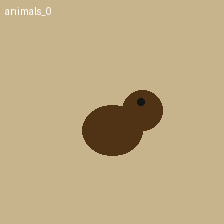


TOP 5 SIMILAR IMAGES:

[1] animals_00.png (category: animals, score: 1.0000)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/animals/animals_00.png


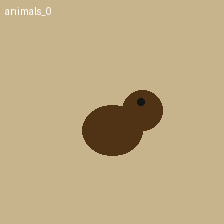


[2] animals_03.png (category: animals, score: 0.9132)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/animals/animals_03.png


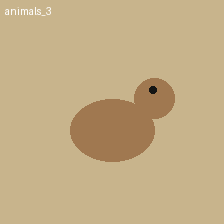


[3] animals_01.png (category: animals, score: 0.9077)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/animals/animals_01.png


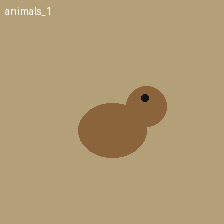


[4] animals_05.png (category: animals, score: 0.8817)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/animals/animals_05.png


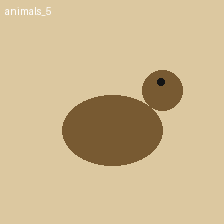


[5] animals_02.png (category: animals, score: 0.8811)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/animals/animals_02.png


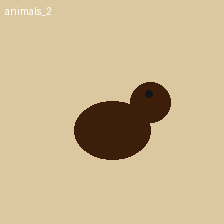


Top 2 similar images: animals_00.png, animals_03.png

✓ Similarity search complete!
✓ Top 2 similar images: animals_00.png, animals_03.png


In [0]:
# Run similarity search and display results
if test_image_idx < len(image_files):
    top_2 = display_image_results(query_fpath, top_k=5)
    print(f"\n✓ Similarity search complete!")
    print(f"✓ Top 2 similar images: {top_2[0]}, {top_2[1]}")
else:
    print("Please select a valid image index in the previous cell")

In [0]:
print(VOLUME_PATH)

/Volumes/sascha_demo_aws_catalog/image_similarity/images


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
QUERY IMAGE: test_black_tshirt.png


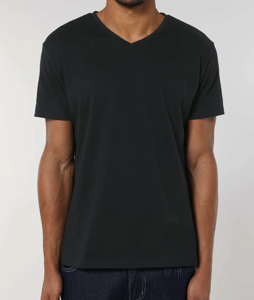


TOP 5 SIMILAR IMAGES:

[1] test_black_tshirt.png (category: hugo, score: 1.0000)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/hugo/test_black_tshirt.png


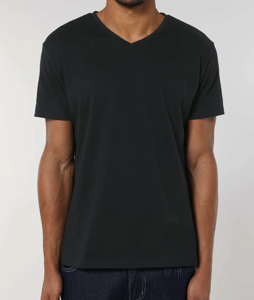


[2] Screenshot 2026-02-11 at 17.44.19.png (category: hugo, score: 0.9085)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/hugo/Screenshot 2026-02-11 at 17.44.19.png


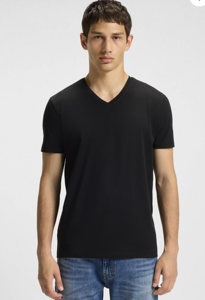


[3] Screenshot 2026-02-11 at 17.47.11.png (category: hugo, score: 0.8996)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/hugo/Screenshot 2026-02-11 at 17.47.11.png


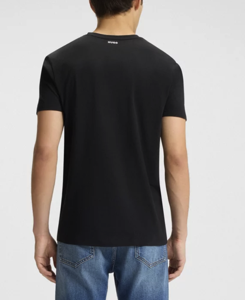


[4] Screenshot 2026-02-11 at 17.47.03.png (category: hugo, score: 0.8847)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/hugo/Screenshot 2026-02-11 at 17.47.03.png


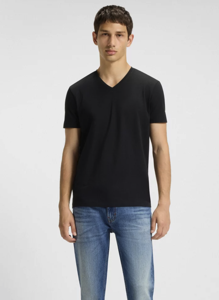


[5] Screenshot 2026-02-11 at 17.44.25.png (category: hugo, score: 0.7985)
    Path: /Volumes/sascha_demo_aws_catalog/image_similarity/images/hugo/Screenshot 2026-02-11 at 17.44.25.png


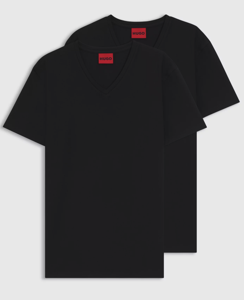


Top 2 similar images: test_black_tshirt.png, Screenshot 2026-02-11 at 17.44.19.png

✓ Similarity search complete!
✓ Top 5 similar images: test_black_tshirt.png, Screenshot 2026-02-11 at 17.44.19.png


In [0]:
# teste mit neuem Bild
test_image_path = f"{VOLUME_PATH}/hugo/test_black_tshirt.png"

# Run similarity search and display results
top_2 = display_image_results(test_image_path, top_k=5)
print(f"\n✓ Similarity search complete!")
print(f"✓ Top 5 similar images: {top_2[0]}, {top_2[1]}")

## 6 | Operational Utilities

In [0]:
# Row count & category breakdown
display(spark.sql(f"""
SELECT category, COUNT(*) as image_count
FROM {IMAGE_TABLE}
GROUP BY category
ORDER BY category
"""))

In [0]:
# Index status check
idx = vsc.get_index(VS_ENDPOINT_NAME, VS_INDEX_NAME)
desc = idx.describe()
print(f"Index status:  {desc.get('status', {})}")
print(f"Num docs:      {desc.get('status', {}).get('indexed_row_count', 'N/A')}")

## 7 | Cleanup (Optional)

Uncomment and run the cells below to remove all demo resources.

In [0]:
# # --- UNCOMMENT TO CLEAN UP ---
# # Delete Vector Search index
# vsc.delete_index(VS_ENDPOINT_NAME, VS_INDEX_NAME)
# print(f"Deleted index {VS_INDEX_NAME}")
#
# # Delete Vector Search endpoint
# vsc.delete_endpoint(VS_ENDPOINT_NAME)
# print(f"Deleted endpoint {VS_ENDPOINT_NAME}")
#
# # Drop table
# spark.sql(f"DROP TABLE IF EXISTS {IMAGE_TABLE}")
# print(f"Dropped table {IMAGE_TABLE}")